# 📊 Exploratory Data Analysis (EDA)
## Sri Lanka Paddy Production Analysis (2004-2023)

**Objective:** Analyze historical paddy production patterns across different districts and seasons in Sri Lanka to identify key trends, top-performing regions, and factors influencing production.

**Dataset:** Cleaned paddy production data from 2004 to 2023 covering both Maha and Yala seasons across all districts.

---
## 1. Setup and Data Loading

In [14]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load cleaned dataset
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'paddy_data_cleaned.csv'))

# Standardize year format for consistent visualization
# Convert "2004 - 2005" to "2005" to match Yala season format
def simplify_year(year_str):
    """Extract the end year from Maha season format (e.g., '2004 - 2005' -> '2005')"""
    if '-' in str(year_str):
        return year_str.split('-')[1].strip()
    return str(year_str).strip()

df['Year_Clean'] = df['Year'].apply(simplify_year)
df = df.sort_values('Year_Clean')

# Filter out aggregated totals (keep only individual districts)
df = df[~df['District'].str.upper().str.contains('SRI', na=False)]

print(f"✅ Data Loaded Successfully!")
print(f"📅 Period: {df['Year_Clean'].min()} - {df['Year_Clean'].max()}")
print(f"📍 Districts: {df['District'].nunique()}")
print(f"📊 Total Records: {len(df):,}")
print("\n" + "="*60)
display(df[['Year', 'Year_Clean', 'Season', 'District', 'Total_Production']].head())

✅ Data Loaded Successfully!
📅 Period: 2005 - 2023
📍 Districts: 34
📊 Total Records: 1,000



,Year,Year_Clean,Season,District,Total_Production
0,2004 - 2005,2005,Maha,COLOMBO,12687.0
56,2005,2005,Yala,KALUTARA,24656.0
57,2005,2005,Yala,GALLE,20369.0
58,2005,2005,Yala,MATARA,35843.0
59,2005,2005,Yala,RATNAPURA,26532.0


---
## 2. Temporal Analysis: Production Trends Over Time

Analyzing how paddy production has evolved across the two main cultivation seasons (Maha and Yala) from 2004 to 2023.

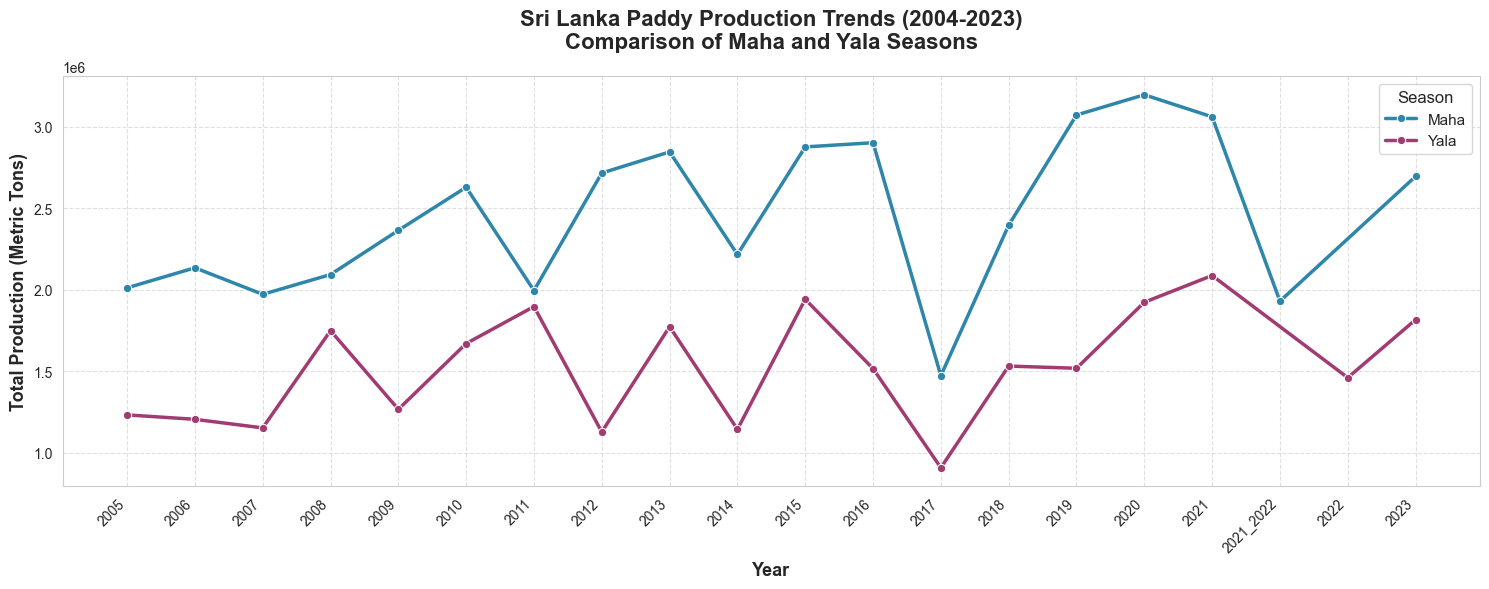


📈 Key Insights:
   • Maha Season Average Production: 2,452,384 MT
   • Yala Season Average Production: 1,523,250 MT
   • Maha produces 61.0% more than Yala on average


In [15]:
# Aggregate production by year and season
annual_production = df.groupby(['Year_Clean', 'Season'])['Total_Production'].sum().reset_index()

# Create visualization
fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=annual_production, 
    x='Year_Clean', 
    y='Total_Production', 
    hue='Season', 
    marker='o', 
    linewidth=2.5,
    palette=['#2E86AB', '#A23B72']
)

plt.title('Sri Lanka Paddy Production Trends (2004-2023)\nComparison of Maha and Yala Seasons', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total Production (Metric Tons)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Season', title_fontsize=12, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

# Summary statistics
maha_avg = annual_production[annual_production['Season'] == 'Maha']['Total_Production'].mean()
yala_avg = annual_production[annual_production['Season'] == 'Yala']['Total_Production'].mean()

print(f"\n📈 Key Insights:")
print(f"   • Maha Season Average Production: {maha_avg:,.0f} MT")
print(f"   • Yala Season Average Production: {yala_avg:,.0f} MT")
print(f"   • Maha produces {((maha_avg/yala_avg - 1) * 100):.1f}% more than Yala on average")

---
## 3. Geographic Analysis: Top Rice Producing Districts

Identifying which districts contribute most significantly to Sri Lanka's total paddy production.

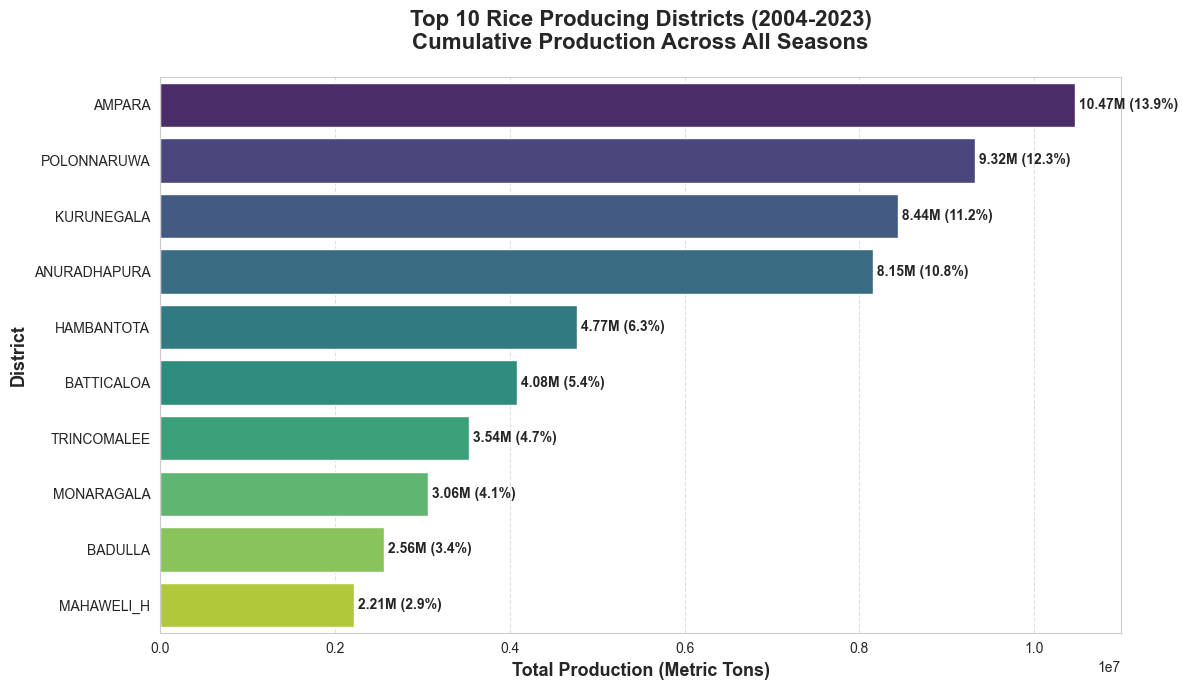


🏆 Top 3 Districts:
   1. AMPARA: 10,467,861 MT (13.9% of total)
   2. POLONNARUWA: 9,320,738 MT (12.3% of total)
   3. KURUNEGALA: 8,435,250 MT (11.2% of total)

📊 Top 10 districts account for 74.9% of total production


In [16]:
# Aggregate total production by district (all years combined)
district_total = df.groupby('District')['Total_Production'].sum().sort_values(ascending=False).reset_index()

# Select top 10 districts
top_10 = district_total.head(10)

# Calculate percentages
total_all_districts = district_total['Total_Production'].sum()
top_10['Percentage'] = (top_10['Total_Production'] / total_all_districts * 100)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = sns.barplot(
    data=top_10, 
    x='Total_Production', 
    y='District', 
    palette='viridis',
    hue='District',
    legend=False
)

# Add value labels on bars
for i, (production, percentage) in enumerate(zip(top_10['Total_Production'], top_10['Percentage'])):
    ax.text(production, i, f' {production/1e6:.2f}M ({percentage:.1f}%)', 
            va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Rice Producing Districts (2004-2023)\nCumulative Production Across All Seasons', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Production (Metric Tons)', fontsize=13, fontweight='bold')
plt.ylabel('District', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n🏆 Top 3 Districts:")
for idx in range(min(3, len(top_10))):
    district = top_10.iloc[idx]['District']
    production = top_10.iloc[idx]['Total_Production']
    percentage = top_10.iloc[idx]['Percentage']
    print(f"   {idx+1}. {district}: {production:,.0f} MT ({percentage:.1f}% of total)")

print(f"\n📊 Top 10 districts account for {top_10['Percentage'].sum():.1f}% of total production")

---
## 4. Correlation Analysis: Production Drivers

Examining the relationships between key agricultural metrics to understand what drives paddy production.

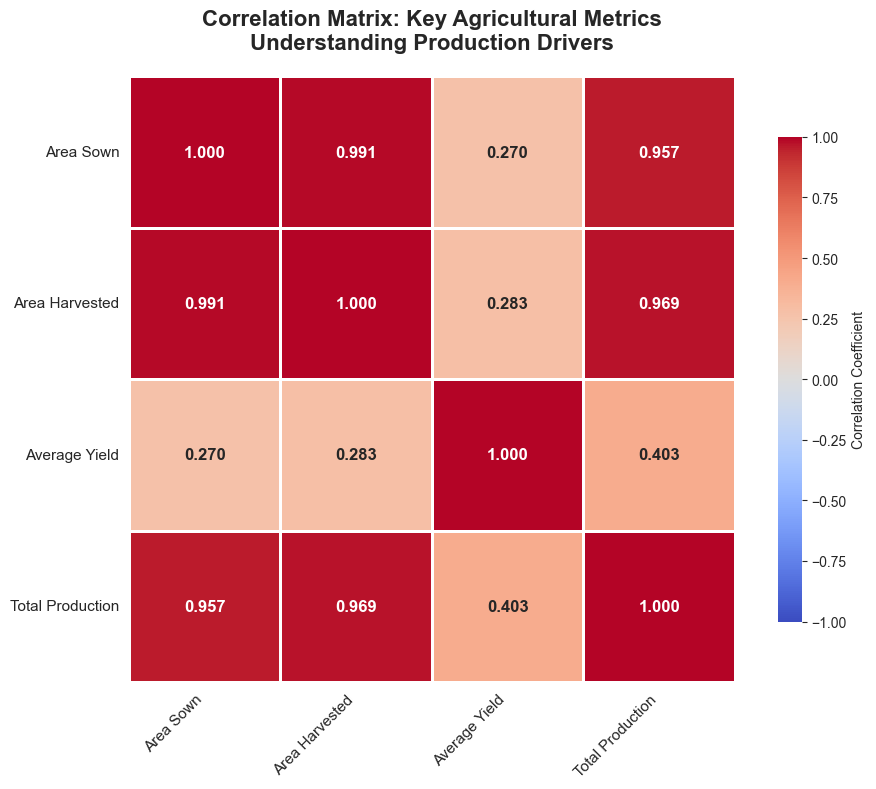


🔍 Key Correlation Insights:
   • Area Sown ↔ Total Production: 0.957
   • Area Harvested ↔ Total Production: 0.969
   • Average Yield ↔ Total Production: 0.403
   • Area Sown ↔ Area Harvested: 0.991

💡 Interpretation:
   Strong positive correlations indicate that production is driven by both
   the area cultivated and the yield per hectare.


In [17]:
# Select relevant numeric columns for correlation analysis
corr_cols = ['All_Schemes_Sown', 'All_Schemes_Harvested', 'Average_Yield', 'Total_Production']
correlation = df[corr_cols].corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation, 
    annot=True, 
    fmt=".3f",
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Correlation Matrix: Key Agricultural Metrics\nUnderstanding Production Drivers', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')

# Improve label readability
labels = ['Area Sown', 'Area Harvested', 'Average Yield', 'Total Production']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(labels, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Print key correlations
print("\n🔍 Key Correlation Insights:")
print(f"   • Area Sown ↔ Total Production: {correlation.loc['All_Schemes_Sown', 'Total_Production']:.3f}")
print(f"   • Area Harvested ↔ Total Production: {correlation.loc['All_Schemes_Harvested', 'Total_Production']:.3f}")
print(f"   • Average Yield ↔ Total Production: {correlation.loc['Average_Yield', 'Total_Production']:.3f}")
print(f"   • Area Sown ↔ Area Harvested: {correlation.loc['All_Schemes_Sown', 'All_Schemes_Harvested']:.3f}")

print("\n💡 Interpretation:")
print("   Strong positive correlations indicate that production is driven by both")
print("   the area cultivated and the yield per hectare.")

---
## 5. Summary of Key Findings

### 📌 Main Insights:

1. **Seasonal Patterns**
   - Maha season consistently produces more rice than Yala season
   - Production shows year-over-year variability, likely due to weather patterns

2. **Geographic Concentration**
   - Top 10 districts account for the majority of total production
   - Ampara, Polonnaruwa, and Kurunegala are the leading rice-producing districts

3. **Production Drivers**
   - Strong correlation between area harvested and total production
   - Both cultivation area and yield per hectare are critical factors

4. **Data Quality**
   - Dataset covers 20 years (2004-2023) with consistent structure
   - Successfully filtered out aggregate totals for accurate district-level analysis

